In [ ]:
import marimo as mo

# VLM Optimization via Genetic Algorithm on MMBench

Pipeline: Baselines (Zero-shot / Few-shot / Manual CoT) -> GA prompt evolution -> Final comparison.

- MMBench dataset
- Qwen2-VL-7B-Instruct
- LLM-based mutation
- 10 GA generations
- Population of 6

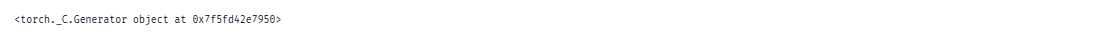

In [ ]:
import os
os.environ["GROQ_API_KEY"] = "abc"
os.environ["HF_TOKEN"] = "abc"
os.environ["GA_STATE_REPO"] = "anamika-lab/mmbench-ga-checkpoints-v3"

import json
import random
import re
import time

import torch
from PIL import Image
from datasets import load_dataset
import matplotlib.pyplot as plt

random.seed(42)
torch.manual_seed(42)


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


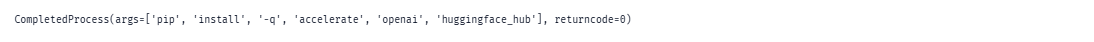

In [ ]:
import subprocess
subprocess.run([
    "pip", "install", "-q",
    "accelerate",
    "openai",
    "huggingface_hub"
])

## Config

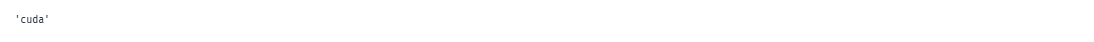

In [ ]:
# ---- CONFIG ----
MODEL_ID = "Qwen/Qwen2-VL-7B-Instruct"

# VLM phase in the proposal: 10 generations.
N_VAL = 500
N_TEST = 1500
N_FEWSHOT = 3
POP_SIZE = 6
N_GENERATIONS = 10

# Molab continuation/checkpoint protocol.
CHECKPOINT_EVERY = 5
TIME_LIMIT_HOURS = 11.0
STATE_FILE = "ga_state_gen.json"

# Proposal: an LLM is the evolutionary operator.
# Default: GPT-4o-mini. A compatible Llama-3 endpoint can be substituted.
META_MODEL = os.getenv("GA_META_MODEL", "openai/gpt-oss-20b")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

# Persistent Hugging Face Hub repository for GA checkpoints.
HF_STATE_REPO = os.getenv("GA_STATE_REPO", "")
HF_TOKEN = os.getenv("HF_TOKEN")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

## Load the VLM (Qwen2-VL-7B-Instruct)


Fetching 5 files: 100%|██████████| 5/5 [00:43<00:00,  8.64s/it]

Loading weights: 100%|██████████| 730/730 [00:02<00:00, 316.55it/s]


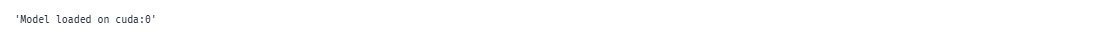

In [ ]:
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info

# Handle device mapping more carefully
if DEVICE == "cuda":
    try:
        model = Qwen2VLForConditionalGeneration.from_pretrained(
            MODEL_ID,
            torch_dtype=torch.bfloat16,
            device_map="auto",
        )
    except ValueError as e:
        model = Qwen2VLForConditionalGeneration.from_pretrained(
            MODEL_ID,
            torch_dtype=torch.bfloat16,
        ).to(DEVICE)
else:
    model = Qwen2VLForConditionalGeneration.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.float32,
    )

processor = AutoProcessor.from_pretrained(MODEL_ID)

def run_vlm(image, prompt: str, max_new_tokens: int = 64) -> str:
    """Single image + text prompt -> model's text response."""
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": prompt},
            ],
        }
    ]
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    ).to(model.device)
    with torch.no_grad():
        gen_ids = model.generate(
            **inputs, max_new_tokens=max_new_tokens, do_sample=False
        )
    gen_ids_trimmed = [
        out[len(inp):] for inp, out in zip(inputs.input_ids, gen_ids)
    ]
    output = processor.batch_decode(
        gen_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=True
    )[0]
    return output.strip()

f"Model loaded on {model.device}"

## Load MMBench subset


Generating dev split: 100%|██████████| 4377/4377 [00:00<00:00, 21536.55 examples/s]

Generating test split: 100%|██████████| 6718/6718 [00:00<00:00, 32702.89 examples/s]


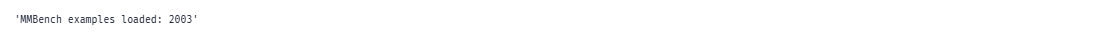

In [ ]:
mmbench_raw = load_dataset("lmms-lab/MMBench_EN", split="dev")  # streaming removed

NEEDED = N_VAL + N_TEST + N_FEWSHOT
indices = random.sample(range(len(mmbench_raw)), NEEDED)
mmbench_examples = [mmbench_raw[i] for i in indices]

f"MMBench examples loaded: {len(mmbench_examples)}"

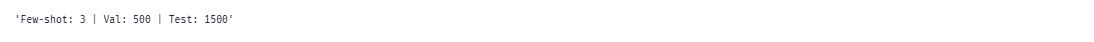

In [ ]:
OPTION_KEYS = ["A", "B", "C", "D"]

def format_options(ex):
    lines = []
    for key in OPTION_KEYS:
        val = ex.get(key)
        if val is None:
            continue
        val = str(val).strip()
        if not val or val.lower() == "nan":  # some rows only have 2-3 options
            continue
        lines.append(f"{key}. {val}")
    return "\n".join(lines)

def normalize(ex):
    image = ex.get("image")
    question = ex.get("question")
    answer = ex.get("answer")
    options_text = format_options(ex)
    hint = ex.get("hint")

    if image is None or question is None or answer is None or not options_text:
        return None

    full_question = question
    if hint and str(hint).strip().lower() not in ("", "nan"):
        full_question = f"{str(hint).strip()}\n{question}"

    return {
        "image": image,
        "question": full_question,
        "options": options_text,
        "answer": str(answer).strip().upper(),  # gold letter: A/B/C/D
    }

all_examples = [normalize(e) for e in mmbench_examples]
all_examples = [d for d in all_examples if d is not None]
random.shuffle(all_examples)

fewshot_pool = all_examples[:N_FEWSHOT]
val_set = all_examples[N_FEWSHOT : N_FEWSHOT + N_VAL]
test_set = all_examples[N_FEWSHOT + N_VAL : N_FEWSHOT + N_VAL + N_TEST]

dataset = all_examples
f"Few-shot: {len(fewshot_pool)} | Val: {len(val_set)} | Test: {len(test_set)}"

## Answer parsing + scoring helpers

In [ ]:
def extract_final_answer(raw_output: str, options_text: str) -> str:
    """Extract a single option letter (A-D) from the VLM response."""
    text = str(raw_output).strip()

    patterns = [
        r"(?:final\s+answer)\s*[:\-]?\s*\(?([A-D])\)?",
        r"(?:answer)\s*[:\-]?\s*\(?([A-D])\)?",
    ]
    for pattern in patterns:
        match = re.search(pattern, text, flags=re.IGNORECASE)
        if match:
            return match.group(1).upper()

    # Fallback: last standalone A/B/C/D token in the response (models often
    # reason first, e.g. "A dog is visible... so the answer is C" — taking
    # the first match would incorrectly pick up the article "A").
    matches = re.findall(r"\b([A-D])\b", text)
    if matches:
        return matches[-1].upper()

    # Last resort: model answered with the option's text instead of its letter.
    text_lower = text.lower()
    for line in options_text.splitlines():
        letter, _, content = line.partition(". ")
        if content.strip().lower() in text_lower:
            return letter.strip().upper()

    return ""

def is_correct(pred: str, gold: str) -> bool:
    return pred.strip().upper() == gold.strip().upper()

def evaluate_prompt_template(template: str, examples_list: list, verbose: bool = False) -> float:
    """template must contain {question} and {options}; runs on each example, returns accuracy."""
    correct = 0
    for item in examples_list:
        prompt = template.format(question=item["question"], options=item["options"])
        try:
            raw_out = run_vlm(item["image"], prompt)
        except Exception as e:
            if verbose:
                print("Error:", e)
            continue
        pred = extract_final_answer(raw_out, item["options"])
        ok = is_correct(pred, item["answer"])
        correct += int(ok)
        if verbose:
            print(f"Q: {item['question'][:60]} | GT: {item['answer']} | Pred: {pred or '?'} | {'OK' if ok else 'X'}")
    return correct / max(len(examples_list), 1)

## Baseline 1 — Zero-shot

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Q: Based on the image, what might be the purpose of the metal s | GT: A | Pred: B | X
Q: What's the function of the demonstrated object? | GT: B | Pred: B | OK
Q: This event chain shows events from Peter and Wendy by J. M.  | GT: B | Pred: B | OK
Q: Which scene category matches this image the best? | GT: D | Pred: D | OK
Q: What emotion is portrayed in this image? | GT: B | Pred: B | OK
Q: Where is it? | GT: B | Pred: B | OK
Q: The other object that is the same color as the large shiny t | GT: B | Pred: B | OK
Q: Which special day is associated with this poster? | GT: B | Pred: B | OK
Q: What will happen next? | GT: B | Pred: B | OK
Q: The object shown in this figure: | GT: D | Pred: D | OK
Q: What's the profession of the people in this picture? | GT: D | Pred: D | OK
Q: Which Python code can generate the content of the image? | GT: D | Pred: D | OK
Q: In this comparison diagram, are the upper and lower modules  | GT: A | Pred: A | OK
Q: What is the capital of Washington? | GT: C | Pre

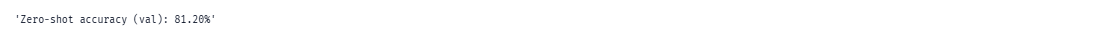

In [ ]:
ZERO_SHOT_TEMPLATE = (
    "Answer with ONLY the letter of the correct option (A, B, C, or D) and nothing else.\n"
    "Question: {question}\nOptions:\n{options}\nAnswer:"
)

zero_shot_acc = evaluate_prompt_template(ZERO_SHOT_TEMPLATE, val_set, verbose=True)
f"Zero-shot accuracy (val): {zero_shot_acc:.2%}"

## Baseline 2 — Few-shot

Q: Based on the image, what might be the purpose of the metal s | GT: A | Pred: B | X
Q: What's the function of the demonstrated object? | GT: B | Pred: B | OK
Q: This event chain shows events from Peter and Wendy by J. M.  | GT: B | Pred: B | OK
Q: Which scene category matches this image the best? | GT: D | Pred: D | OK
Q: What emotion is portrayed in this image? | GT: B | Pred: B | OK
Q: Where is it? | GT: B | Pred: B | OK
Q: The other object that is the same color as the large shiny t | GT: B | Pred: A | X
Q: Which special day is associated with this poster? | GT: B | Pred: B | OK
Q: What will happen next? | GT: B | Pred: B | OK
Q: The object shown in this figure: | GT: D | Pred: D | OK
Q: What's the profession of the people in this picture? | GT: D | Pred: D | OK
Q: Which Python code can generate the content of the image? | GT: D | Pred: D | OK
Q: In this comparison diagram, are the upper and lower modules  | GT: A | Pred: A | OK
Q: What is the capital of Washington? | GT: C | Pred

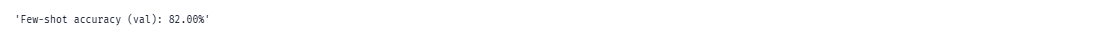

In [ ]:
def build_fewshot_template(pool):
    header = (
        "Answer each question with ONLY the letter of the correct option "
        "(A, B, C, or D), nothing else. Follow the style of the examples below.\n"
    )
    examples_text = ""
    for item in pool:
        examples_text += (
            f"Question: {item['question']}\nOptions:\n{item['options']}\n"
            f"Answer: {item['answer']}\n\n"
        )

    # Escape any literal { } that came from real dataset content (e.g. a
    # question or option describing JSON-like text) so str.format() later
    # doesn't mistake it for a placeholder.
    header = header.replace("{", "{{").replace("}", "}}")
    examples_text = examples_text.replace("{", "{{").replace("}", "}}")

    tail = "Question: {question}\nOptions:\n{options}\nAnswer:"
    return header + examples_text + tail

FEW_SHOT_TEMPLATE = build_fewshot_template(fewshot_pool)
few_shot_acc = evaluate_prompt_template(FEW_SHOT_TEMPLATE, val_set, verbose=True)
f"Few-shot accuracy (val): {few_shot_acc:.2%}"

## Baseline 3 — Manual Visual Chain-of-Thought

Q: Based on the image, what might be the purpose of the metal s | GT: A | Pred: A | OK
Q: What's the function of the demonstrated object? | GT: B | Pred: B | OK
Q: This event chain shows events from Peter and Wendy by J. M.  | GT: B | Pred: B | OK
Q: Which scene category matches this image the best? | GT: D | Pred: D | OK
Q: What emotion is portrayed in this image? | GT: B | Pred: B | OK
Q: Where is it? | GT: B | Pred: B | OK
Q: The other object that is the same color as the large shiny t | GT: B | Pred: B | OK
Q: Which special day is associated with this poster? | GT: B | Pred: B | OK
Q: What will happen next? | GT: B | Pred: B | OK
Q: The object shown in this figure: | GT: D | Pred: D | OK
Q: What's the profession of the people in this picture? | GT: D | Pred: D | OK
Q: Which Python code can generate the content of the image? | GT: D | Pred: D | OK
Q: In this comparison diagram, are the upper and lower modules  | GT: A | Pred: A | OK
Q: What is the capital of Washington? | GT: C | Pr

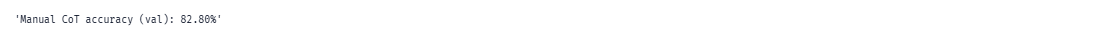

In [ ]:
MANUAL_COT_TEMPLATE = (
    "Look carefully at the image. First, examine each option against what is "
    "visible in the image and rule out options that are clearly incorrect. Then "
    "reason step by step about which remaining option best answers the question. "
    "Finally give your answer as a single letter in the form "
    "'Final answer: <A/B/C/D> - nothing else on that line'.\n\n"
    "Question: {question}\nOptions:\n{options}"
)

manual_cot_acc = evaluate_prompt_template(MANUAL_COT_TEMPLATE, val_set, verbose=True)
f"Manual CoT accuracy (val): {manual_cot_acc:.2%}"

## Genetic Algorithm — initial population

Each individual is a prompt *template* string containing `{question}`.

In [ ]:
INITIAL_POPULATION = [
    "Examine the image carefully, then evaluate each option against the visual "
    "evidence. Answer with only the letter of the correct option.\n"
    "Question: {question}\nOptions:\n{options}\nAnswer:",

    "Identify the object or objects referred to in the question. Check their "
    "appearance, attributes, and relevant details in the image, then eliminate "
    "options that don't match. Give only the letter of the correct option.\n"
    "Question: {question}\nOptions:\n{options}\nAnswer:",

    "Focus on the spatial relationships between the relevant objects in the "
    "image, such as left/right, above/below, inside/outside, near/far. Use "
    "this to decide between the given options.\n"
    "Question: {question}\nOptions:\n{options}\nAnswer:",

    "Inspect the image systematically. For each option, check whether it is "
    "visually supported. A short justification is not needed — respond "
    "with only the letter of the best-supported option.\n"
    "Question: {question}\nOptions:\n{options}\nAnswer:",

    "First locate the entities mentioned or implied by the question, then "
    "verify their relevant visual properties and relationships against each "
    "option. Reason from the image before giving the final letter.\n"
    "Question: {question}\nOptions:\n{options}\nReasoning, then Final answer:",

    "Use the question to determine exactly what visual information matters. "
    "Search the image for that evidence, ignore irrelevant details, and "
    "choose the option best supported by the image.\n"
    "Question: {question}\nOptions:\n{options}\nAnswer:",
]

assert len(INITIAL_POPULATION) == POP_SIZE
assert len(set(INITIAL_POPULATION)) == POP_SIZE

## Mutation + Crossover — LLM evolutionary operators

LLM is used as the mutation and crossover operator.
Each VLM chromosome contains visual-grounding, reasoning, and answer-format instructions.

In [ ]:
# ---- LLM evolutionary operators ----
from openai import OpenAI, RateLimitError

if not GROQ_API_KEY:
    raise RuntimeError(
        "GROQ_API_KEY is not set. "
        "Add your Groq API key before running the GA."
    )

meta_client = OpenAI(
    api_key=GROQ_API_KEY,
    base_url="https://api.groq.com/openai/v1"
)

PROMPT_OPERATOR_SYSTEM = """You are an evolutionary prompt optimizer for a Vision-Language Model (VLM).

Your task is to create improved VLM prompt templates for multiple-choice visual question answering on MMBench.

You are creating PROMPTS, not answering the questions.

Every generated prompt MUST:
1. Preserve the literal placeholders {question} and {options} exactly.
2. Tell the VLM to inspect the image before answering.
3. Direct attention to information relevant to the question rather than describing the entire image.
4. Encourage appropriate visual reasoning when required, including:
   - object identification
   - attributes such as color, size, shape, or appearance
   - spatial relationships
   - object relationships
   - counting
   - comparison
5. Avoid assuming that every question requires all of these reasoning types.
6. Require the final answer to be ONLY the letter of the correct option (A, B, C, or D).
7. Avoid adding unnecessary instructions that could distract from the visual task.

For MUTATION:
- Preserve the strongest useful ideas from the parent.
- Change at least one meaningful reasoning strategy or instruction.
- Do not merely rephrase the parent.
- Do not merely append a generic sentence.
- Produce a genuinely different candidate.

For CROSSOVER:
- Combine complementary strengths from both parents.
- Select useful visual reasoning strategies from each parent.
- Produce a coherent new prompt rather than concatenating the parents.
- Do not simply copy either parent.

Avoid:
- mentioning genetic algorithms, mutation, crossover, fitness, or evolution
- referring to the prompt as a chromosome
- giving answers to the question
- inventing information about the image
- excessive chain-of-thought instructions
- unnecessarily long prompts

Return ONLY valid JSON in exactly this form:
{"prompt": "..."}
"""

def _parse_operator_output(text):
    text = text.strip()
    text = re.sub(r"^```(?:json)?\s*", "", text, flags=re.I)
    text = re.sub(r"\s*```$", "", text)

    data = json.loads(text)
    prompt = data["prompt"]

    if not isinstance(prompt, str) or "{question}" not in prompt or "{options}" not in prompt:
        raise ValueError("Operator output must contain {question} and {options}.")

    return prompt.strip()

def llm_mutate(parent):
    user = f"""Improve this VLM prompt through a meaningful mutation.

Parent prompt:
{parent}

Create ONE genuinely different offspring prompt.

Choose one or more of these mutation directions:
- improve visual grounding
- improve object identification
- improve attribute recognition
- improve spatial reasoning
- improve object-to-object relationship reasoning
- improve counting or comparison
- improve question-focused visual search
- improve ambiguity handling
- improve concise final-answer extraction

The offspring should preserve useful ideas from the parent, but it MUST introduce
a substantive change in reasoning strategy or instruction.

Do NOT:
- merely replace a few words with synonyms
- merely append one generic sentence
- copy the parent unchanged
- add unnecessary chain-of-thought verbosity
- answer the question itself

The offspring MUST:
- preserve {{question}} exactly
- remain a prompt template for the VLM
- instruct the VLM to use the image
- end with a clear concise-answer requirement

Parent:
{parent}
"""

    response = meta_client.chat.completions.create(
        model=META_MODEL,
        temperature=0.9,
        max_tokens=300,
        messages=[
            {
                "role": "system",
                "content": PROMPT_OPERATOR_SYSTEM
            },
            {
                "role": "user",
                "content": user
            },
        ],
    )

    return _parse_operator_output(
        response.choices[0].message.content
    )

def llm_crossover(parent_a, parent_b):
    user = f"""Create ONE new VLM prompt by performing a genuine crossover
between these two parent prompts.

PARENT A:
{parent_a}

PARENT B:
{parent_b}

First identify the strongest useful strategy in each parent, then combine
their complementary strengths into ONE coherent prompt.

The child should preferably combine different capabilities, for example:
- visual grounding + spatial reasoning
- object identification + attribute reasoning
- question-focused search + relationship reasoning
- counting/comparison + visual verification
- ambiguity handling + precise answer extraction

The child MUST introduce a meaningful combination of ideas from both parents.

Do NOT:
- copy Parent A unchanged
- copy Parent B unchanged
- simply concatenate the two prompts
- merely replace words with synonyms
- merely append one sentence to a parent
- include explanations of your editing process
- answer the question
- mention genetic algorithms, crossover, mutation, or evolution

The resulting prompt MUST:
- preserve {{question}} exactly
- instruct the VLM to inspect the image
- focus reasoning on information relevant to the question
- use visual evidence rather than assumptions
- support spatial, relational, attribute, counting, or comparison reasoning when relevant
- require a concise final answer

Return only the new prompt through the required JSON format.
"""

    response = meta_client.chat.completions.create(
        model=META_MODEL,
        temperature=0.9,
        max_tokens=300,
        messages=[
            {
                "role": "system",
                "content": PROMPT_OPERATOR_SYSTEM
            },
            {
                "role": "user",
                "content": user
            },
        ],
    )

    return _parse_operator_output(
        response.choices[0].message.content
    )

def call_with_backoff(fn, *args, max_retries=4):
    """Retry an operator call through transient rate limits.
    Raises RateLimitError if the budget is genuinely exhausted."""
    for attempt in range(max_retries):
        try:
            return fn(*args)
        except RateLimitError:
            if attempt == max_retries - 1:
                raise
            wait = min(30 * (2 ** attempt), 240)
            print(f"Rate limited; sleeping {wait}s before retry {attempt + 2}/{max_retries}")
            time.sleep(wait)

def validate_prompt(prompt):
    return (
        isinstance(prompt, str)
        and "{question}" in prompt
        and "{options}" in prompt
        and 20 <= len(prompt.strip()) <= 5000
    )

def prompt_token_length(prompt):
    return len(prompt.split())

def tournament_select(scored_pop, k=2, exclude=None):
    pool = [item for item in scored_pop if item[0] != exclude]

    if not pool:
        pool = list(scored_pop)

    candidates = random.sample(
        pool,
        min(k, len(pool))
    )

    return max(
        candidates,
        key=lambda item: item[1]
    )[0]

fitness_cache = {}

In [ ]:
def fitness(template: str) -> float:
    # Cache identical chromosomes so elites do not consume VLM calls repeatedly.
    if template in fitness_cache:
        return fitness_cache[template]
    acc = evaluate_prompt_template(template, val_set)
    fitness_cache[template] = acc
    return acc

def chromosome_metrics(template, generation, accuracy):
    return {
        "generation": int(generation),
        "accuracy": float(accuracy),
        "prompt_token_length": prompt_token_length(template),
        "prompt": template,
    }

In [ ]:
def next_generation(scored_pop: list) -> list:
    scored_sorted = sorted(scored_pop, key=lambda x: x[1], reverse=True)

    # Keep the best two individuals unchanged (elitism).
    new_pop = [t for t, _ in scored_sorted[:2]]

    # Generate the remaining individuals through evolutionary operators.
    attempts = 0
    max_attempts = POP_SIZE * 3

    while len(new_pop) < POP_SIZE and attempts < max_attempts:
        attempts += 1

        parent_a = tournament_select(scored_sorted, k=2)
        parent_b = tournament_select(scored_sorted, k=2, exclude=parent_a)

        try:
            # Crossover creates a new combination of parent strategies.
            child = call_with_backoff(llm_crossover, parent_a, parent_b)

            # Mutation provides additional exploration.
            if random.random() < 0.30:
                child = call_with_backoff(llm_mutate, child)

            if not validate_prompt(child):
                continue

            # Do not allow an unchanged parent or duplicate offspring.
            if child in new_pop:
                continue

            new_pop.append(child)

        except RateLimitError as e:
            # Budget exhausted: stop hammering the API. The fallback below
            # refills the population from existing individuals.
            print(f"Rate limit exhausted; ending operator phase for this generation: {e}")
            break

        except Exception as e:
            print(
                f"Evolutionary operator error: "
                f"{type(e).__name__}: {e}"
            )

    # If the LLM operator fails repeatedly, use remaining scored
    # individuals only as a safety fallback.
    if len(new_pop) < POP_SIZE:
        for candidate, _ in scored_sorted:
            if candidate not in new_pop:
                new_pop.append(candidate)

            if len(new_pop) >= POP_SIZE:
                break

    return new_pop[:POP_SIZE]

## GA evolution loop + Hall of Fame

In [ ]:
# ============================================================
# GA EVOLUTION + HALL OF FAME + CHECKPOINT/RESUME
from huggingface_hub import HfApi, hf_hub_download, upload_file

def save_state_local(current_gen, population, hall_of_fame):
    state = {'current_gen': int(current_gen), 'population': population, 'hall_of_fame': hall_of_fame, 'fitness_cache': fitness_cache, 'status': 'PARTIAL'}
    with open(STATE_FILE, 'w', encoding='utf-8') as f:
        json.dump(state, f, indent=2)
    return state

def push_state_to_hub():
    if not HF_STATE_REPO or not HF_TOKEN:
        print('HF checkpoint skipped: GA_STATE_REPO/HF_TOKEN not configured.')
        return
    try:
        api = HfApi(token=HF_TOKEN)
        api.create_repo(repo_id=HF_STATE_REPO, repo_type='model', exist_ok=True, private=True)
        upload_file(path_or_fileobj=STATE_FILE, path_in_repo=STATE_FILE, repo_id=HF_STATE_REPO, repo_type='model', token=HF_TOKEN)
        print(f'Checkpoint pushed: {HF_STATE_REPO}/{STATE_FILE}')
    except Exception as e:
        print(f'HF checkpoint push failed (local save still succeeded): {type(e).__name__}: {e}')

def load_state():
    if not HF_STATE_REPO or not HF_TOKEN:
        return None
    try:
        path = hf_hub_download(repo_id=HF_STATE_REPO, filename=STATE_FILE, repo_type='model', token=HF_TOKEN)
        with open(path, 'r', encoding='utf-8') as f:
            return json.load(f)
    except Exception as e:
        print(f'No remote checkpoint found: {type(e).__name__}')
        return None
remote_state = load_state()
if remote_state:
    current_gen = int(remote_state['current_gen'])
    ga_population = remote_state['population']
    hall_of_fame = remote_state.get('hall_of_fame', [])
    fitness_cache.update(remote_state.get('fitness_cache', {}))
    print(f'Resuming from generation {current_gen}.')
else:
    current_gen = 0
    ga_population = INITIAL_POPULATION
    hall_of_fame = []
    print('Starting a fresh GA run.')
experiment_start = time.time()
try:
    while current_gen < N_GENERATIONS:
        elapsed_hours = (time.time() - experiment_start) / 3600.0
        if elapsed_hours >= TIME_LIMIT_HOURS:
            print('Time limit reached; saving resumable state.')
            save_state_local(current_gen, ga_population, hall_of_fame)
            push_state_to_hub()
            break
        scored = []
        for template in ga_population:
            acc = fitness(template)
            scored.append((template, acc))
            print(f"Gen {current_gen} | acc={acc:.2%} | tokens={prompt_token_length(template)} | {template[:100].replace(chr(10), ' ')}...")
        scored.sort(key=lambda x: x[1], reverse=True)
        best_template, best_acc = scored[0]
        hall_of_fame.append(chromosome_metrics(best_template, current_gen, best_acc))
        mean_acc = sum((a for _, a in scored)) / len(scored)
        unique_count = len(set((t for t, _ in scored)))
        print(f'--- Gen {current_gen}: best={best_acc:.2%}, mean={mean_acc:.2%}, unique={unique_count}/{len(scored)} ---')
        ga_population = next_generation(scored)
        current_gen = current_gen + 1
        save_state_local(current_gen, ga_population, hall_of_fame)
        if current_gen % CHECKPOINT_EVERY == 0:
            push_state_to_hub()
finally:
    save_state_local(current_gen, ga_population, hall_of_fame)
    push_state_to_hub()
if current_gen >= N_GENERATIONS:
    final_state = save_state_local(current_gen, ga_population, hall_of_fame)
    final_state['status'] = 'COMPLETE'
    with open(STATE_FILE, 'w', encoding='utf-8') as f:
        json.dump(final_state, f, indent=2)
    push_state_to_hub()  # Leave one hour of safety margin before the 12-hour Molab limit.
    print('GA finished all requested generations.')
hall_of_fame  # Hall of Fame: best chromosome from each completed generation.  # Create offspring only after evaluating the current generation.  # Save every generation locally; push every 5 generations.  # Graceful save on timeout/disconnect/error.

No remote checkpoint found: RemoteEntryNotFoundError
Starting a fresh GA run.
Gen 0 | acc=81.80% | tokens=26 | Examine the image carefully, then evaluate each option against the visual evidence. Answer with only...
Gen 0 | acc=81.80% | tokens=39 | Identify the object or objects referred to in the question. Check their appearance, attributes, and ...
Gen 0 | acc=76.40% | tokens=31 | Focus on the spatial relationships between the relevant objects in the image, such as left/right, ab...
Gen 0 | acc=81.80% | tokens=34 | Inspect the image systematically. For each option, check whether it is visually supported. A short j...
Gen 0 | acc=76.00% | tokens=38 | First locate the entities mentioned or implied by the question, then verify their relevant visual pr...
Gen 0 | acc=78.20% | tokens=33 | Use the question to determine exactly what visual information matters. Search the image for that evi...
--- Gen 0: best=81.80%, mean=79.33%, unique=6/6 ---
Evolutionary operator error: JSONDecodeError: Un

No files have been modified since last commit. Skipping to prevent empty commit.


Checkpoint pushed: anamika-lab/mmbench-ga-checkpoints-v3/ga_state_gen.json
Checkpoint pushed: anamika-lab/mmbench-ga-checkpoints-v3/ga_state_gen.json
GA finished all requested generations.


## Select best GA prompt overall

In [ ]:
best_record = max(hall_of_fame, key=lambda x: x["accuracy"])

best_gen = best_record["generation"]
BEST_GA_TEMPLATE = best_record["prompt"]
best_ga_val_acc = best_record["accuracy"]

print(
    f"Best GA prompt: generation={best_gen}, "
    f"validation accuracy={best_ga_val_acc:.2%}, "
    f"prompt tokens={best_record['prompt_token_length']}"
)
print(BEST_GA_TEMPLATE)

Best GA prompt: generation=3, validation accuracy=82.00%, prompt tokens=46
Look at the image and locate the object(s) mentioned in the question. Examine their attributes, positions, and relationships. For each option, check if it matches the visual evidence; discard any that do not. Return only the letter of the correct option.

Question: {question}
Options:
{options}
Answer:


In [ ]:
# ---- Hall-of-Fame analysis ----
print("Generation | Fitness | Prompt tokens")
for r in hall_of_fame:
    print(
        f"{r['generation']:10d} | "
        f"{r['accuracy']:.2%} | "
        f"{r['prompt_token_length']:13d}"
    )

print("\nBest evolved VLM prompt:")
print(BEST_GA_TEMPLATE)

Generation | Fitness | Prompt tokens
         0 | 81.80% |            26
         1 | 81.80% |            26
         2 | 81.80% |            26
         3 | 82.00% |            46
         4 | 82.00% |            46
         5 | 82.00% |            46
         6 | 82.00% |            46
         7 | 82.00% |            46
         8 | 82.00% |            46
         9 | 82.00% |            46

Best evolved VLM prompt:
Look at the image and locate the object(s) mentioned in the question. Examine their attributes, positions, and relationships. For each option, check if it matches the visual evidence; discard any that do not. Return only the letter of the correct option.

Question: {question}
Options:
{options}
Answer:


## Final comparison on held-out TEST set

Same test set for all 4 methods.

In [ ]:
results = {'Zero-shot': evaluate_prompt_template(ZERO_SHOT_TEMPLATE, test_set), 'Few-shot': evaluate_prompt_template(FEW_SHOT_TEMPLATE, test_set), 'Manual CoT': evaluate_prompt_template(MANUAL_COT_TEMPLATE, test_set), 'GA-best': evaluate_prompt_template(BEST_GA_TEMPLATE, test_set)}
for method, acc_1 in results.items():
    print(f'{method:12s}: {acc_1:.2%}')

Zero-shot   : 84.73%
Few-shot    : 83.67%
Manual CoT  : 84.73%
GA-best     : 84.67%


## Visualize comparison

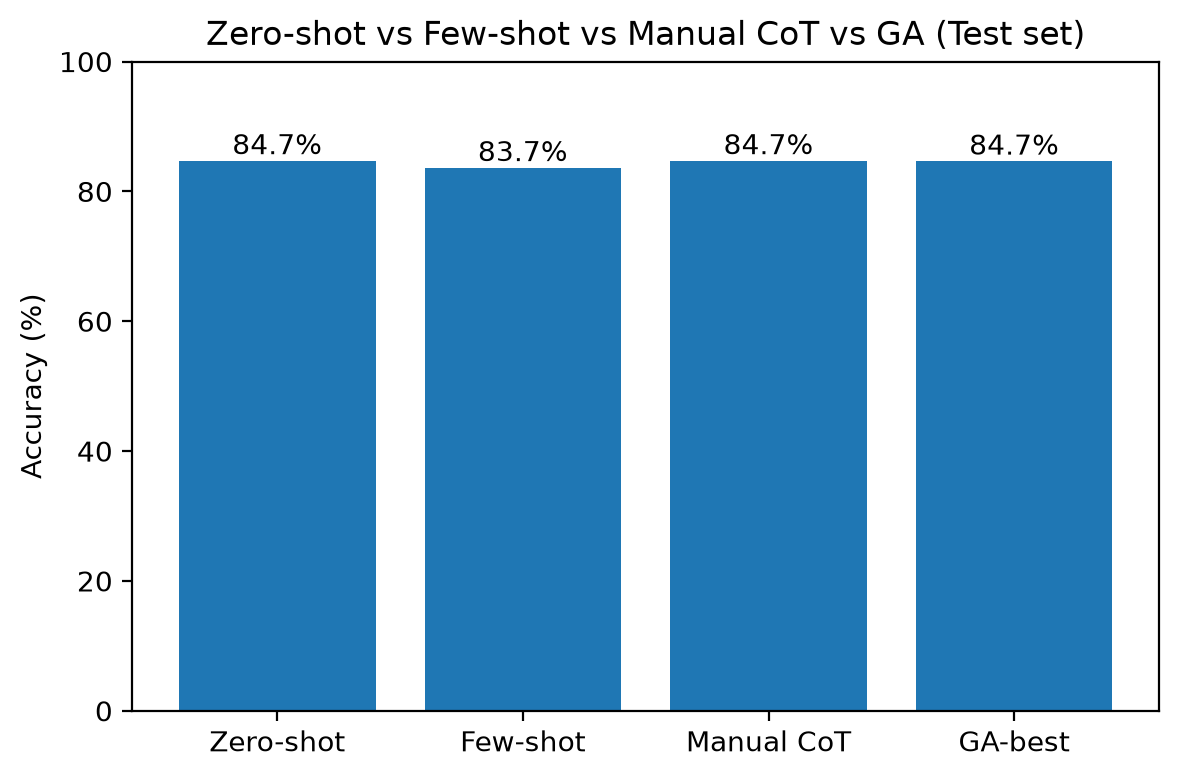

In [ ]:
methods = list(results.keys())
accs = [results[m] * 100 for m in methods]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(methods, accs)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Zero-shot vs Few-shot vs Manual CoT vs GA (Test set)")
for idx, v in enumerate(accs):
    ax.text(idx, v + 1, f"{v:.1f}%", ha="center")
ax.set_ylim(0, 100)
fig.tight_layout()
fig